In [ ]:
import os
from PIL import Image
import cv2
import numpy as np
import pandas as pd
import random

def yolo_img_info(img_path, annotation_line):
    '''get image info from cropped area defined by YOLO annotation
    parameters:
    img_path: file path to full size image
    annotation_line: YOLO annotation'''

    try:
        # read image and get shape
        img = cv2.imread(img_path)
        H, W, _ = img.shape
        
        # Parse YOLO
        parts = list(map(float, annotation_line.split()))
        _, xc, yc, w, h = parts
        
        # Convert to pixel coordinates
        x1 = int(((xc - w/2) * W)-(W*0.00))
        y1 = int(((yc - h/2) * H)-(H*0.00))
        x2 = int(((xc + w/2) * W)+(W*0.00))
        y2 = int(((yc + h/2) * H)+(H*0.00))
        
        # define cropped area
        cropped = img[y1:y2, x1:x2]

        # convert cropped image to HSV
        hsv = cv2.cvtColor(cropped, cv2.COLOR_BGR2HSV)

        # get image brightness
        v_channel = hsv[:, :, 2]
        avg_brightness = np.mean(v_channel)

        # define dictionary with image info
        row_dict = {"img_height": H,
                    "img_width": W,
                    "anno_ctr_x": xc,
                    "anno_ctr_y": yc,
                    "cropped_height": x2-x1, 
                    "cropped_width": y2-y1,
                    "brightness" : avg_brightness}

        # append to dictionary list
        list_dictionary.append(row_dict)

    except Exception as e:
        print(e)

img_files = r"../data/license_plate_detection/test/images"
anno_files = r"../data/license_plate_detection/test/labels"

# get file list from images files
files = os.listdir(img_files)

# random sample of files
test_f_list = random.sample(files, k=100) 

# remove .jpg file name for generic file name
generic_fns = [file.replace(".jpg","") for file in test_f_list]

# define list for storing dictionaries
global list_dictionary
list_dictionary = []

for file in generic_fns:
    
    # define image and annotation file paths
    img_file, anno_file = file+".jpg", file+".txt"
    ann_fp = f"{anno_files}/{anno_file}"
    img_fp = f"{img_files}/{img_file}"

    # read first line of annoation
    with open(ann_fp, "r") as f:
        annotation = f.readlines()[0]

    # run image info function
    yolo_img_info(img_fp, annotation)

# convert list dictionary to dataframe
df = pd.DataFrame(list_dictionary)

,img_height,img_width,anno_ctr_x,anno_ctr_y,cropped_height,cropped_width,brightness
0,193,261,0.568008,0.535155,164,88,132.089385
1,303,472,0.639831,0.665017,93,21,150.821301
2,303,472,0.644068,0.521452,45,13,125.287179
3,480,640,0.682227,0.662802,191,74,167.202844
4,980,1306,0.559487,0.553500,417,132,177.509865
...,...,...,...,...,...,...,...
95,416,416,0.424279,0.575721,104,47,106.986907
96,657,1000,0.778500,0.621005,60,27,121.945679
97,1280,960,0.831236,0.431883,120,84,102.391369
98,303,472,0.547669,0.757426,103,27,139.783172


<Axes: xlabel='anno_ctr_x', ylabel='anno_ctr_y'>

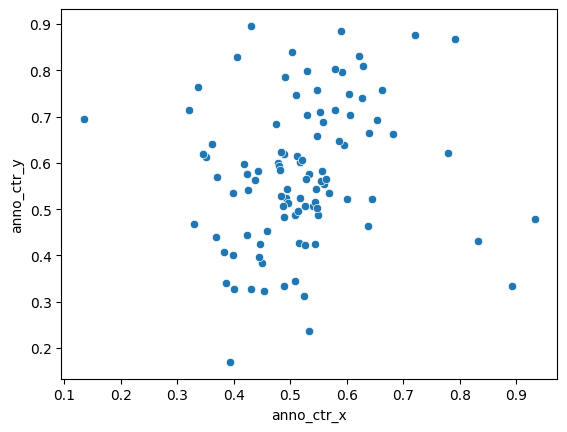

In [30]:
import seaborn as sns

sns.scatterplot(df, x = "anno_ctr_x", y = "anno_ctr_y")


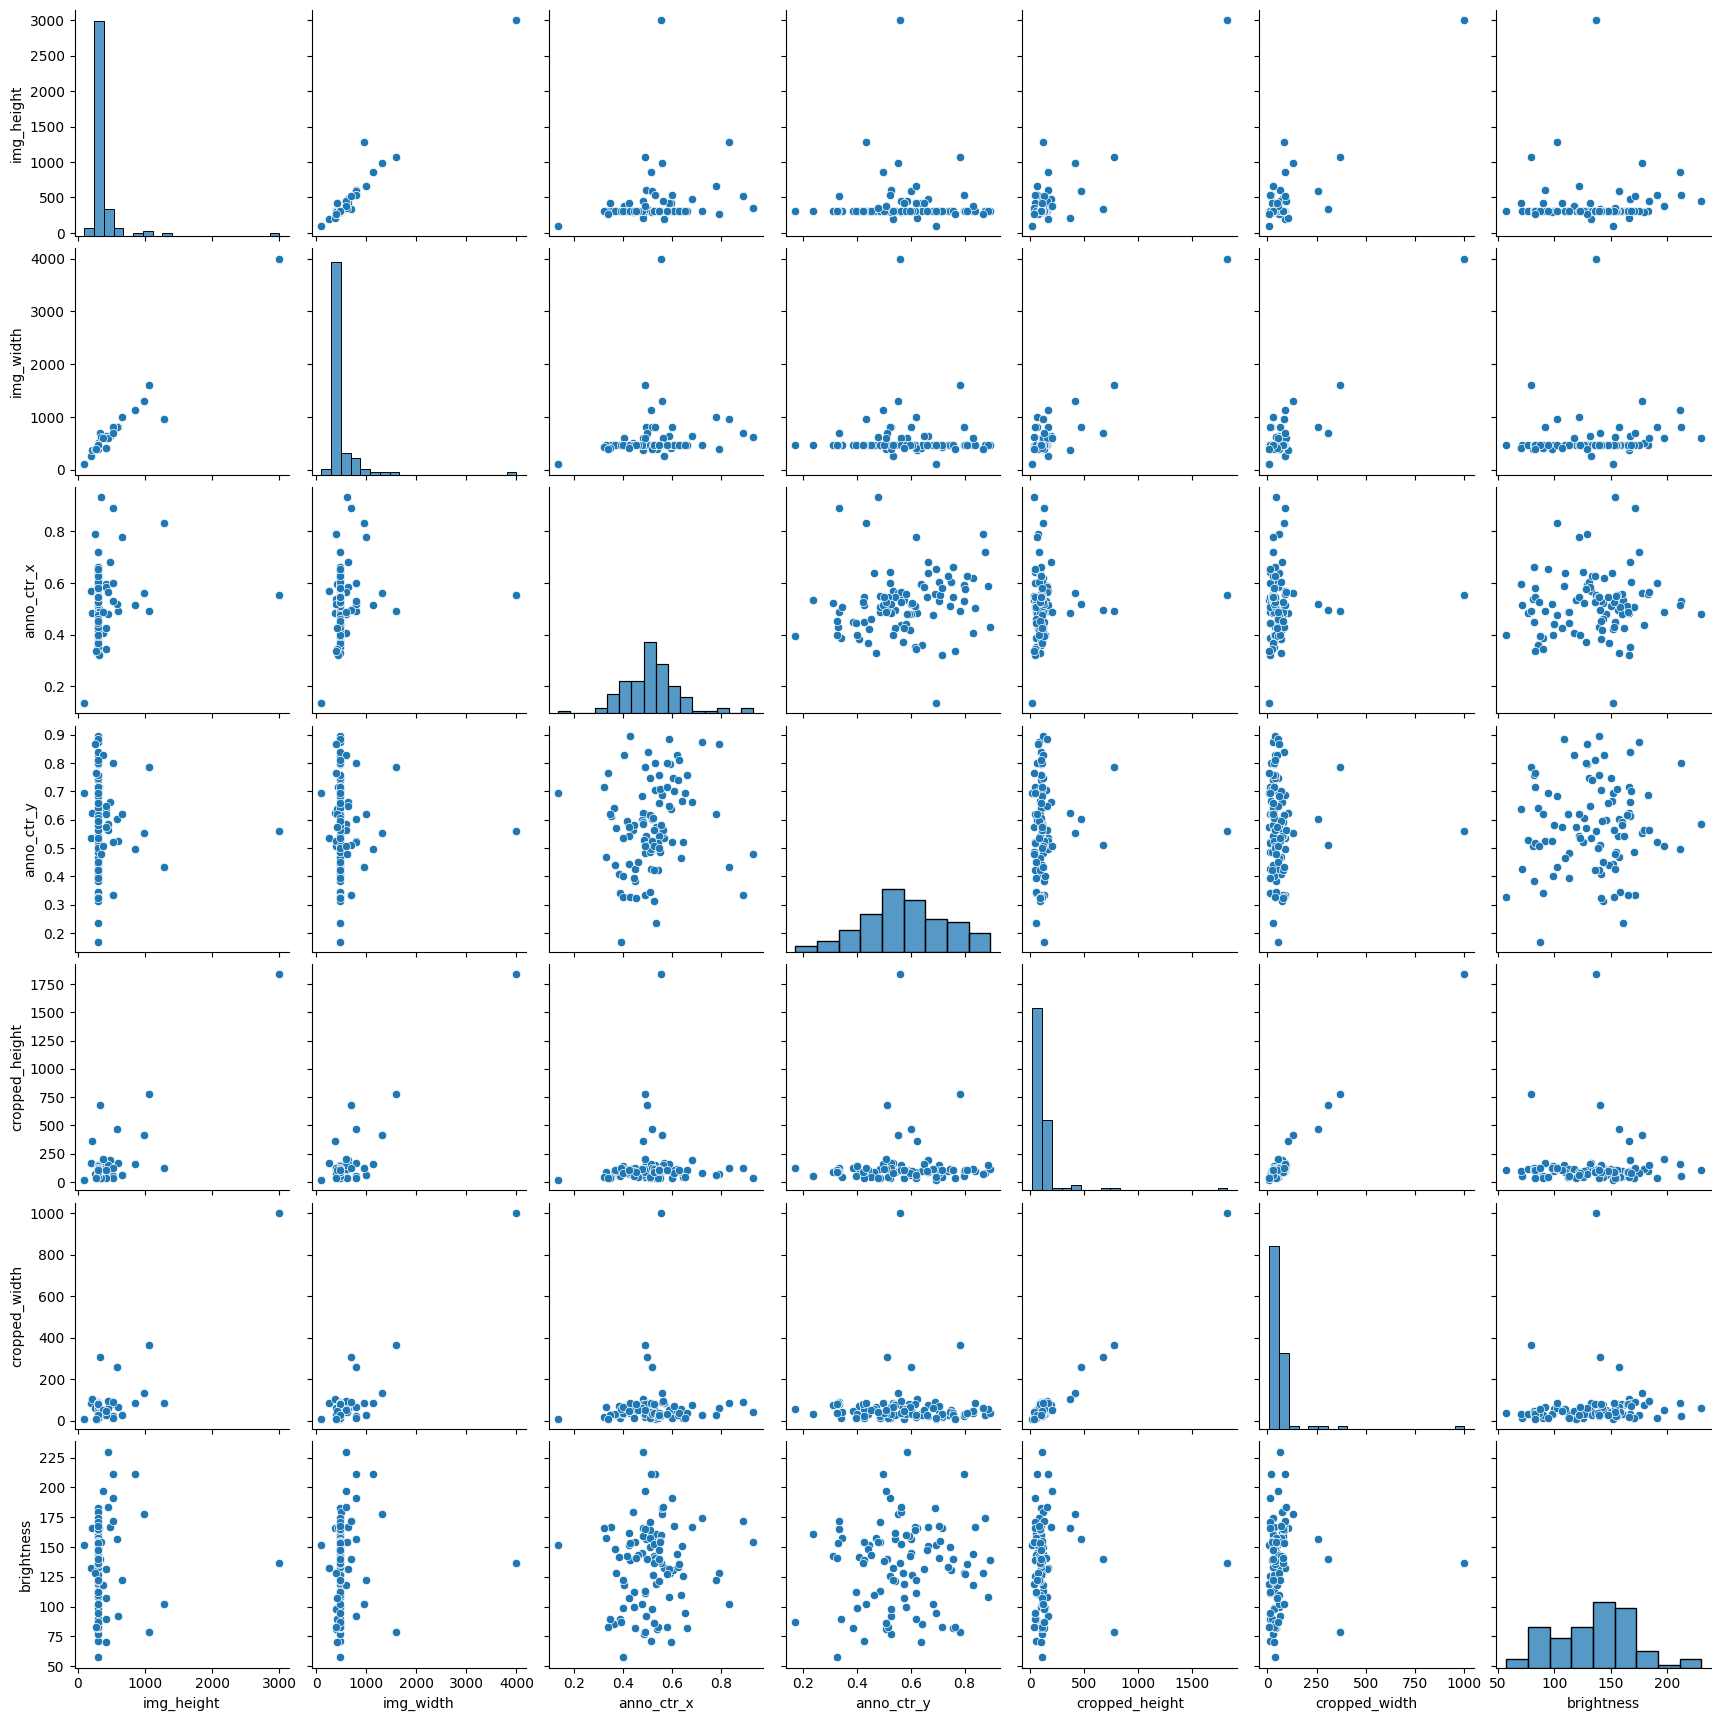

In [32]:
import seaborn as sns

sns.pairplot(df)